In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data = {
    "Experience": [1,2,3,4,5,6],
    "Education": [12,12,15,16,18,18],
    "Skills": [2,3,4,5,6,7],
    "Salary": [25000,30000,38000,47000,60000,70000]
}

df = pd.DataFrame(data)

print(df)

   Experience  Education  Skills  Salary
0           1         12       2   25000
1           2         12       3   30000
2           3         15       4   38000
3           4         16       5   47000
4           5         18       6   60000
5           6         18       7   70000


In [3]:
X = df[['Experience','Education','Skills']]
y = df['Salary']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
model = LinearRegression()

In [6]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[4821.43,1142.86,4821.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['Experience','Education','Skills']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.361e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


In [7]:
y_pred = model.predict(X_test)

In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

print(comparison)

   Actual     Predicted
0   25000  14571.428571
1   30000  24214.285714


In [9]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE =", mae)

MAE = 8107.142857142848


In [10]:
mse = mean_squared_error(y_test, y_pred)
print("MSE =", mse)

MSE = 71114795.9183672


In [11]:
rmse = np.sqrt(mse)
print("RMSE =", rmse)

RMSE = 8432.95890647922


In [12]:
r2 = r2_score(y_test, y_pred)
print("R2 Score =", r2)

R2 Score = -10.378367346938752


In [13]:
print("Intercept =", model.intercept_)

Intercept = -13607.142857142855


In [14]:
new_employee = [[7,18,8]]

salary = model.predict(new_employee)

print("Predicted Salary =", salary)

Predicted Salary = [79285.71428571]


c:\Users\danny\OneDrive\Documents\coding\PBEL (Project-Based Experiential Learning) sessions\PBEL12\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


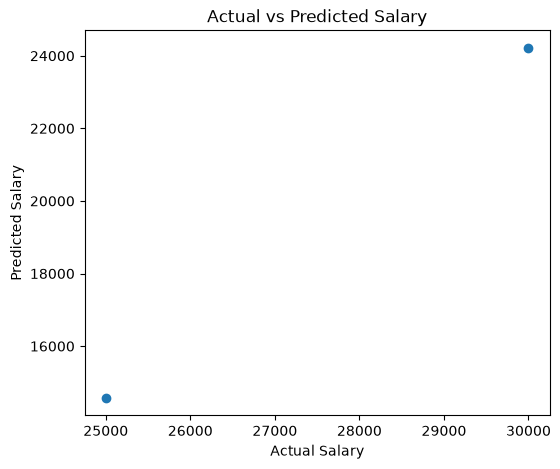

In [15]:
plt.figure(figsize=(6,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

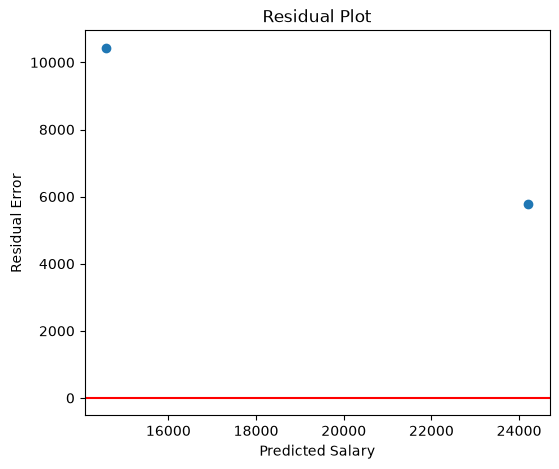

In [16]:
errors = y_test - y_pred

plt.figure(figsize=(6,5))

plt.scatter(y_pred, errors)

plt.axhline(y=0,color='red')

plt.xlabel("Predicted Salary")
plt.ylabel("Residual Error")

plt.title("Residual Plot")

plt.show()

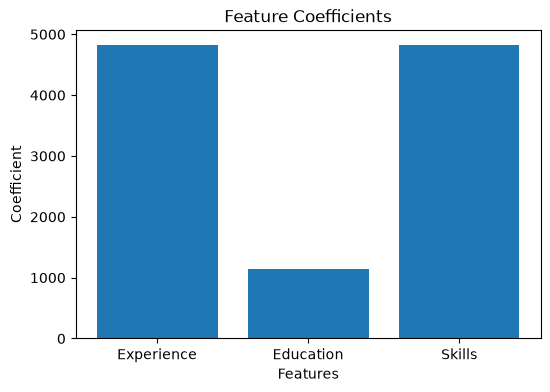

In [17]:
plt.figure(figsize=(6,4))

plt.bar(X.columns, model.coef_)

plt.title("Feature Coefficients")

plt.xlabel("Features")

plt.ylabel("Coefficient")

plt.show()

In [18]:
print(model.score(X_train, y_train))

0.9970076006942367


In [19]:
print("Intercept =", model.intercept_)

for feature, coef in zip(X.columns, model.coef_):
    print(feature, "=", coef)

Intercept = -13607.142857142855
Experience = 4821.42857142857
Education = 1142.857142857144
Skills = 4821.428571428569
